# Preparation

## 1. Importing libraries and files

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import json
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import os

pd.options.display.float_format = '{:.2f}'.format
print("OK")

OK


In [3]:
main_dir = "../.."
raw_data = pd.read_csv(f"{main_dir}/data/raw/raw_dataset.csv")
dataset = pd.read_csv(f"{main_dir}/data/clean_dataset.csv")
cords = pd.read_csv(f"{main_dir}/data/external/cords.csv", dtype={"xcords":str, "ycords":str})
with open(f"{main_dir}/data/external/be.json") as f:
    be = json.load(f)
    f.close()
colors = {"color1": "#127FC3",
          "color3": "#C6104D",
          "color4": "#47C550",
          "color2": "#F2D544",
          "facecolor": "#F7F7F7",
          "facecolor2": "#D7D7D7"
}
print("OK")

OK


Checking raw dataset

In [4]:
raw_data.isna().sum()

Locality                     0
Type of property             0
Subtype of property          0
Price                      513
Number of rooms            541
Living Area               1773
Terrace Area             16413
Garden Area              21076
Surface of the land      13331
Number of facades         6305
State of the building     6113
Furnished                    0
Terrace                      0
Garden                       0
Swimming pool                0
dtype: int64

There is a lot data to clean.
- We may remove terace area and garder area because these fields almost empty. Also we have boolean value about these parameters.
- State of building was changed to numbers.
- Priceless rows removed
- Surface of the land was filled with 0 when NA for appartments
- Locality cleaned and changed to Region + Municipality
- Created indexing of rows. We prevent duplicates in data, so all properties are unique even if looks same
- All collumns renamed for friendly coding.

In [5]:
dataset.head()

,index,type,subtype,price,living_area,land_area,facades,state,furnished,terrace,garden,pool,region,municipality
0,0,house,residence,90000,120,235,2,2,False,True,True,False,Walloon Region,Chièvres
1,1,apartment,apartment,90000,49,0,2,6,False,True,False,False,Walloon Region,Charleroi
2,2,house,residence,90000,165,1410,4,2,False,False,True,False,Walloon Region,Frasnes-lez-Anvaing
3,3,house,residence,90000,115,269,2,2,False,True,False,False,Walloon Region,Dour
4,4,house,residence,90000,113,170,2,2,False,True,True,False,Walloon Region,Dour


## Removing number of rooms

In [6]:
rooms = dataset.iloc[100:-100,3:6]
rooms.price = rooms.price.apply(lambda x: round(x / 100000) * 100000)
rooms = rooms.groupby("price").mean().reset_index()
print("Correlation between Living area and Number of rooms is: ",
      rooms.corr().iloc[1,2] * 100 // 1 / 100, sep = "")

Correlation between Living area and Number of rooms is: 0.74


KeyError: 'Number of rooms'

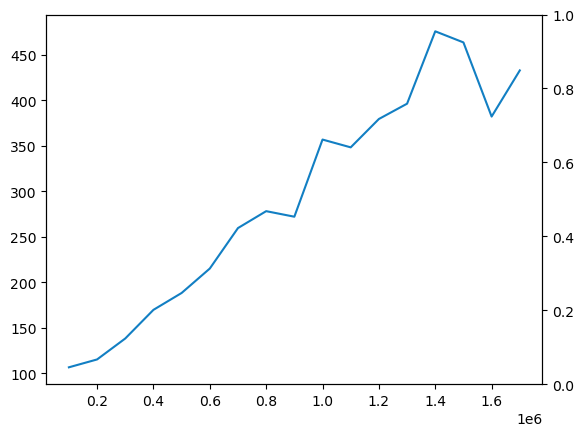

In [7]:
fig, ax = plt.subplots()
l1, = ax.plot(rooms.price, rooms.living_area, color = colors["color1"], label = "Living area")
ax2 = ax.twinx()
l2, = ax2.plot(rooms.price, rooms["Number of rooms"], color = colors["color2"], label = "Number of rooms")
ax.legend(handles = [l1, l2])
ax.set_xlabel("Price")
ax.ticklabel_format(style="plain", axis = "x")
ax.tick_params(axis="x", rotation=45)
ax.set_ylabel("Area")
ax2.set_ylabel("Number of rooms")
ax.set_facecolor(color = colors["facecolor"])
plt.show()
fig.savefig("plots/number_of_rooms.png", bbox_inches="tight")

For this reason Number of rooms was removed from data. Because as price depended on Living area - it is same way depended on Number of rooms.

# Analysis

## Living area to Price ratio

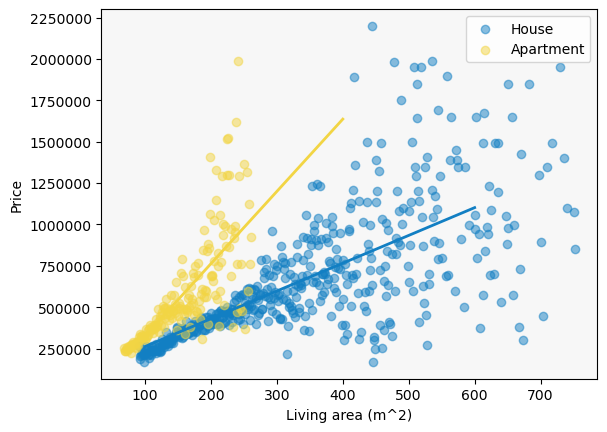

In [8]:
house_living_area = dataset[dataset.type == "house"].groupby("living_area")["price"].mean().to_frame().reset_index().iloc[50:-50]
apartment_living_area = dataset[dataset.type == "apartment"].groupby("living_area")["price"].mean().to_frame().reset_index().iloc[50:-50]
fig, ax = plt.subplots()
ax.scatter(house_living_area.living_area, house_living_area.price, color=colors["color1"], alpha = .5)
ax.scatter(apartment_living_area.living_area, apartment_living_area.price, color=colors["color2"], alpha = .5)
line_house = np.poly1d(np.polyfit(house_living_area.living_area, house_living_area.price, 1))
line_apartment = np.poly1d(np.polyfit(apartment_living_area.living_area, apartment_living_area.price, 1))
line_xrange_house = np.linspace(100, 600)
line_xrange_apartment = np.linspace(100, 400)
ax.plot(line_xrange_house, line_house(line_xrange_house), color=colors["color1"], lw=2)
ax.plot(line_xrange_apartment, line_apartment(line_xrange_apartment), color=colors["color2"], lw=2)

ax.legend(["House", "Apartment"])
ax.set_xlabel("Living area (m^2)")
ax.set_ylabel("Price")
ax.ticklabel_format(style='plain', axis='y')
ax.set_facecolor(colors["facecolor"])
plt.show()
# fig.savefig("plots/living_area_to_price.png", bbox_inches="tight")

In [9]:
dataset[dataset.type == "apartment"].sort_values("living_area", ascending = False).iloc[10:,1:5].head(10)

,type,subtype,price,living_area
13734,apartment,apartment,895000,444
12486,apartment,apartment,595000,430
14012,apartment,apartment,1100000,429
12644,apartment,apartment,610000,403
14210,apartment,duplex,1390000,399
11015,apartment,apartment,480000,380
13946,apartment,apartment,998800,376
13947,apartment,penthouse,999000,370
14023,apartment,apartment,1125000,368
13469,apartment,loft,795000,365


In [10]:
print("Correlation between Living area and Price for houses is: ",
      house_living_area.corr().iloc[0, 1] * 100 // 1 / 100, sep = "")
print("Correlation between Living area and Price for apartments is: ",
      apartment_living_area.corr().iloc[0, 1] * 100 // 1 / 100, sep = "")

Correlation between Living area and Price for houses is: 0.7
Correlation between Living area and Price for apartments is: 0.74


## Price based on Subtype

Checking if **STD** is lower than **MEAN**.

In [11]:
temp = dataset.groupby("subtype")["price"].agg(["std", "mean"])
temp.iloc[:,:]
temp

,std,mean
subtype,,
apartment,213127.33,339361.34
bungalow,118409.25,342454.55
chalet,109047.98,232887.10
cottage,319355.61,547416.05
duplex,227636.91,380773.80
ground-floor,190489.42,333665.01
loft,292508.40,494618.40
mansion,436643.04,1237500.00
master-house,433594.17,688747.46


Results: **STD** gives lower values than **MEAN**. So we can use **MEAN** to create Bar Chart for Subtypes and Prices.

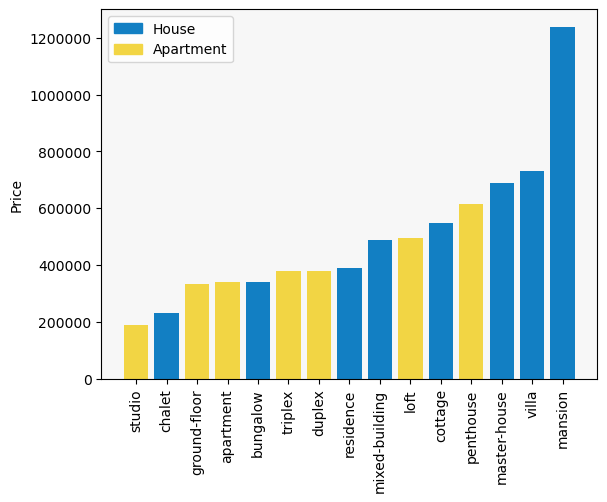

In [12]:
subtypes = dataset.groupby(["type", "subtype"])["price"].mean().to_frame().reset_index().sort_values("price")
subtypes["color"] = subtypes["type"].apply(lambda x: colors["color1"] if x == "house" else colors["color2"])
legend = [
    Patch(color=colors["color1"], label = "House"),
    Patch(color=colors["color2"], label = "Apartment")
]
fig, ax = plt.subplots()
ax.bar(subtypes.subtype, subtypes.price, color=subtypes.color)
ax.legend(handles = legend)
ax.set_ylabel("Price")
ax.ticklabel_format(style="plain", axis="y")
ax.set_facecolor(colors["facecolor"])
plt.xticks(rotation=90)
plt.show()
# fig.savefig("plots/house_type.png", bbox_inches="tight")

## Locality

In [13]:
loc = dataset[["type", "price", "region", "municipality"]]
loc_w = loc[loc.region == "Walloon Region"].groupby("municipality")["price"].mean().to_frame().reset_index().sort_values("price")
loc_f = loc[loc.region == "Flemish Region"].groupby("municipality")["price"].mean().to_frame().reset_index().sort_values("price")
loc_b = loc[loc.region == "Brussels-Capital Region"].groupby("municipality")["price"].mean().to_frame().reset_index().sort_values("price")
mun = {}
for i, line in cords.iterrows():
    mun[line["municipality"]] = [line["xcords"], line["ycords"]]

In [14]:
high_w = loc_w.tail(10)["municipality"].to_list()
low_w = loc_w.head(10)["municipality"].to_list()
high_f = loc_f.tail(10)["municipality"].to_list()
low_f = loc_f.head(10)["municipality"].to_list()
high_b = loc_b.tail(5)["municipality"].to_list()
low_b = loc_b.head(5)["municipality"].to_list()

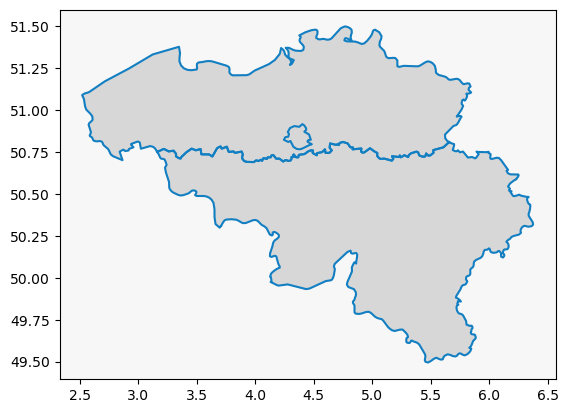

In [15]:
def outer_ring_of_largest(geom):
    coords = geom["coordinates"]
    if geom["type"] == "Polygon":
        return coords[0]
    else:
        largest_poly = max(coords, key=lambda poly: len(poly[0]))
        return largest_poly[0]

fig, ax = plt.subplots()

ring = outer_ring_of_largest(be["features"][1]["geometry"])
xs = [p[0] for p in ring]
ys = [p[1] for p in ring]
ax.fill(xs, ys, color=colors["facecolor2"])
ax.plot(xs, ys, color=colors["color1"])
ring = outer_ring_of_largest(be["features"][2]["geometry"])
xs = [p[0] for p in ring]
ys = [p[1] for p in ring]
ax.fill(xs, ys, color=colors["facecolor2"])
ax.plot(xs, ys, color=colors["color1"])
ring = outer_ring_of_largest(be["features"][0]["geometry"])
xs = [p[0] for p in ring]
ys = [p[1] for p in ring]
ax.plot(xs, ys, color=colors["color1"])
ax.set_facecolor(color = colors["facecolor"])
plt.show()

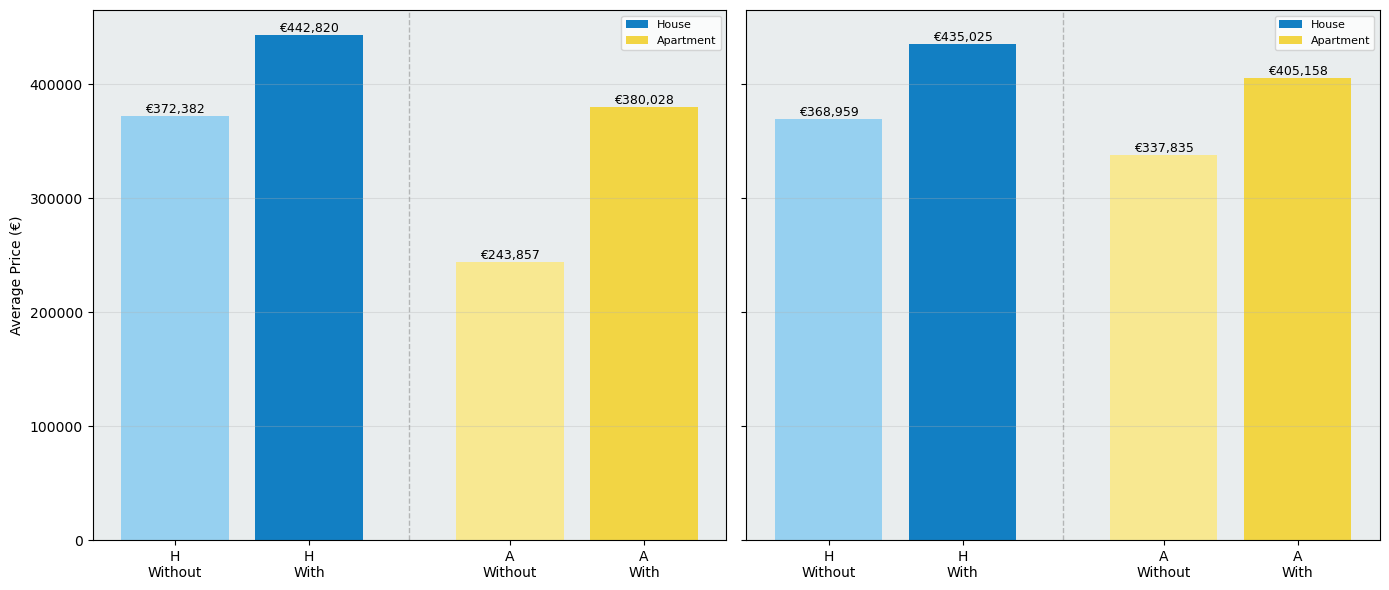

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

features = ['terrace', 'garden']
titles = ['Terrace', 'Garden']

for idx, (feature, title) in enumerate(zip(features, titles)):
    
    ax = axes[idx]

    # Calculate for houses
    house_with = dataset[(dataset.type == 'house') & (dataset[feature] == True)]['price'].mean()
    house_without = dataset[(dataset.type == 'house') & (dataset[feature] == False)]['price'].mean()

    # Calculate for apartments
    apt_with = dataset[(dataset.type == 'apartment') & (dataset[feature] == True)]['price'].mean()
    apt_without = dataset[(dataset.type == 'apartment') & (dataset[feature] == False)]['price'].mean()

    # Bar positions
    x_positions = [0, 1, 2.5, 3.5]
    categories = ['H\nWithout', 'H\nWith', 'A\nWithout', 'A\nWith']
    values = [house_without, house_with, apt_without, apt_with]

    colors = ['#96D0F0', '#127FC3', '#F8E891', "#F2D544"]

    bars = ax.bar(x_positions, values, color=colors, alpha=1, width=0.8)

    # Value labels
    for bar in bars:
        height = bar.get_height()
        if not np.isnan(height):
            ax.text(
                bar.get_x() + bar.get_width()/2.,
                height,
                f'€{height:,.0f}',
                ha='center',
                va='bottom',
                fontsize=9
            )

    ax.set_xticks(x_positions)
    ax.set_xticklabels(categories)

    # Separation line
    ax.axvline(x=1.75, color='gray', linestyle='--', linewidth=1, alpha=0.5)

    if idx == 0:
        ax.set_ylabel("Average Price (€)")
    # ax.set_title(title)
    ax.ticklabel_format(style='plain', axis='y')
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_facecolor("#E9EDEE")

    # Legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#127FC3', label='House'),
        Patch(facecolor='#F2D544', label='Apartment')
    ]
    ax.legend(handles=legend_elements, loc='upper right', fontsize=8)

# plt.suptitle("Impact of Features on Price: Houses vs Apartments", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()
# os.makedirs("plots", exist_ok=True)
fig.savefig("plots/terrace_garden.png", bbox_inches="tight")

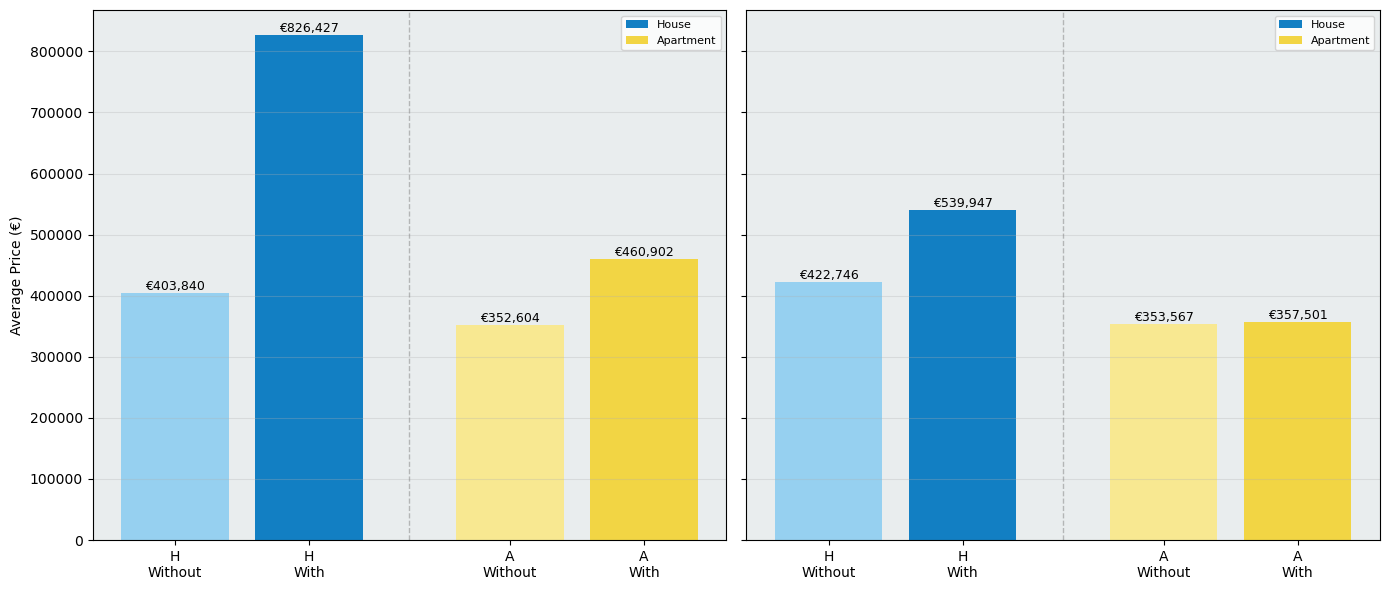

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

features = ['pool', 'furnished']
titles = ['Pool', 'Furnished']

for idx, (feature, title) in enumerate(zip(features, titles)):
    
    ax = axes[idx]

    # Calculate for houses
    house_with = dataset[(dataset.type == 'house') & (dataset[feature] == True)]['price'].mean()
    house_without = dataset[(dataset.type == 'house') & (dataset[feature] == False)]['price'].mean()

    # Calculate for apartments
    apt_with = dataset[(dataset.type == 'apartment') & (dataset[feature] == True)]['price'].mean()
    apt_without = dataset[(dataset.type == 'apartment') & (dataset[feature] == False)]['price'].mean()

    # Bar positions
    x_positions = [0, 1, 2.5, 3.5]
    categories = ['H\nWithout', 'H\nWith', 'A\nWithout', 'A\nWith']
    values = [house_without, house_with, apt_without, apt_with]

    colors = ['#96D0F0', '#127FC3', '#F8E891', "#F2D544"]

    bars = ax.bar(x_positions, values, color=colors, alpha=1, width=0.8)

    # Value labels
    for bar in bars:
        height = bar.get_height()
        if not np.isnan(height):
            ax.text(
                bar.get_x() + bar.get_width()/2.,
                height,
                f'€{height:,.0f}',
                ha='center',
                va='bottom',
                fontsize=9
            )

    ax.set_xticks(x_positions)
    ax.set_xticklabels(categories)

    # Separation line
    ax.axvline(x=1.75, color='gray', linestyle='--', linewidth=1, alpha=0.5)

    if idx == 0:
        ax.set_ylabel("Average Price (€)")
    # ax.set_title(title)
    ax.ticklabel_format(style='plain', axis='y')
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_facecolor("#E9EDEE")

    # Legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#127FC3', label='House'),
        Patch(facecolor='#F2D544', label='Apartment')
    ]
    ax.legend(handles=legend_elements, loc='upper right', fontsize=8)

# plt.suptitle("Impact of Features on Price: Houses vs Apartments", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()
fig.savefig("plots/pool_furnished.png", bbox_inches="tight")

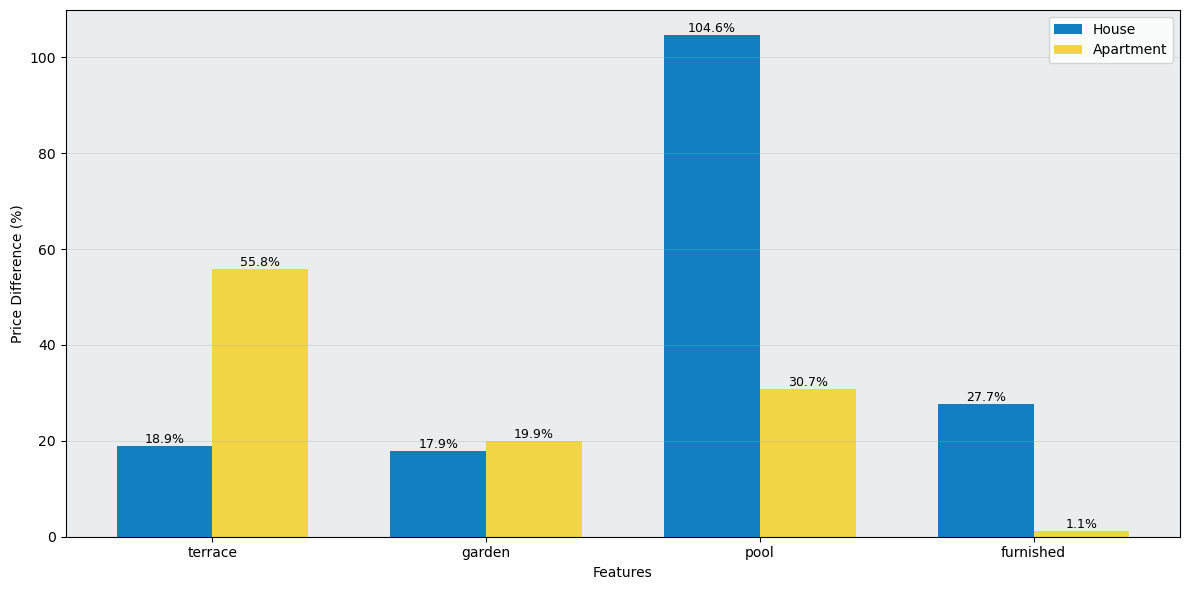

In [49]:
fig, ax = plt.subplots(figsize=(12, 6))

features = ['terrace', 'garden', 'pool', 'furnished']
x = np.arange(len(features))
width = 0.35

house_diffs = []
apt_diffs = []

for feature in features:
    # Houses
    house_with = dataset[(dataset.type == 'house') & (dataset[feature] == True)]['price'].mean()
    house_without = dataset[(dataset.type == 'house') & (dataset[feature] == False)]['price'].mean()
    house_diff = ((house_with - house_without) / house_without) * 100
    house_diffs.append(house_diff)
    
    # Apartments
    apt_with = dataset[(dataset.type == 'apartment') & (dataset[feature] == True)]['price'].mean()
    apt_without = dataset[(dataset.type == 'apartment') & (dataset[feature] == False)]['price'].mean()
    apt_diff = ((apt_with - apt_without) / apt_without) * 100
    apt_diffs.append(apt_diff)

# Create bars
bars1 = ax.bar(x - width/2, house_diffs, width, label='House', color='#127FC3', alpha=1)
bars2 = ax.bar(x + width/2, apt_diffs, width, label='Apartment', color='#F2D544', alpha=1)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        if not np.isnan(height):
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.1f}%', ha='center', va='bottom' if height > 0 else 'top', fontsize=9)

ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax.set_xlabel('Features')
ax.set_ylabel('Price Difference (%)')
# ax.set_title('Percentage Price Impact of Features: Houses vs Apartments')
ax.set_xticks(x)
ax.set_xticklabels(features)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.set_facecolor("#E9EDEE")

plt.tight_layout()
plt.show()
fig.savefig("plots/percentage_price_impact_of_terrace_garden_pool_furnished.png", bbox_inches="tight")

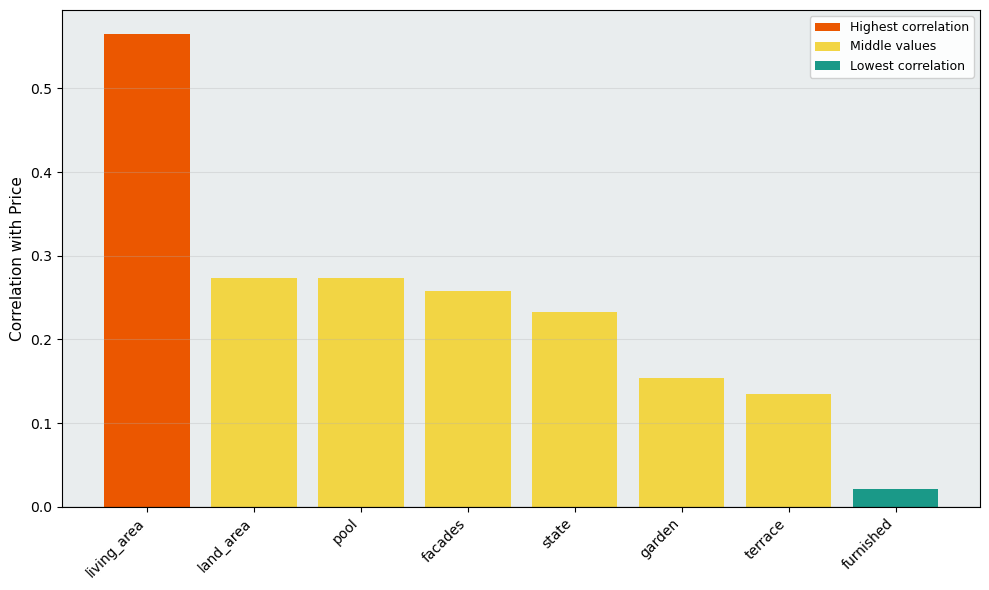

In [53]:
numerical_cols = ['price', 'living_area', 'land_area', 'facades', 'state']
df_numeric = dataset[numerical_cols].copy()

# Convert boolean columns to numeric (0/1) for correlation
df_numeric['furnished'] = dataset['furnished'].astype(int)
df_numeric['terrace'] = dataset['terrace'].astype(int)
df_numeric['garden'] = dataset['garden'].astype(int)
df_numeric['pool'] = dataset['pool'].astype(int)

# Calculate correlations with price
correlations = df_numeric.corr()['price'].drop('price').sort_values(ascending=False)

# Create color list - highest value gets one color, lowest gets another
colors = []
for i, val in enumerate(correlations.values):
    if i == 0:  # highest
        colors.append('#EB5700')  # blue
    elif i == len(correlations) - 1:  # lowest
        colors.append('#1A9988')  # orange
    else:
        colors.append('#F2D544')  # yellow for middle values

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))  # create fig and ax

bars = ax.bar(range(len(correlations)), correlations.values, color=colors)

ax.set_xticks(range(len(correlations)))
ax.set_xticklabels(correlations.index, rotation=45, ha='right')
ax.set_ylabel('Correlation with Price', fontsize=11)

ax.axhline(y=0, color='black', linewidth=0.8, linestyle='-')
ax.grid(axis='y', alpha=0.3)

# Set background color
ax.set_facecolor("#E9EDEE")

# Add legend inside the plot at top right
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#EB5700', label='Highest correlation'),
    Patch(facecolor='#F2D544', label='Middle values'),
    Patch(facecolor='#1A9988', label='Lowest correlation')
]
plt.legend(handles=legend_elements, loc='upper right', fontsize=9, frameon=True, 
           framealpha=0.9, fancybox=True)

plt.tight_layout()
plt.show()
plt.show()
fig.savefig("plots/percentage_price_impact_of_terrace_garden_pool_furnished.png", bbox_inches="tight")

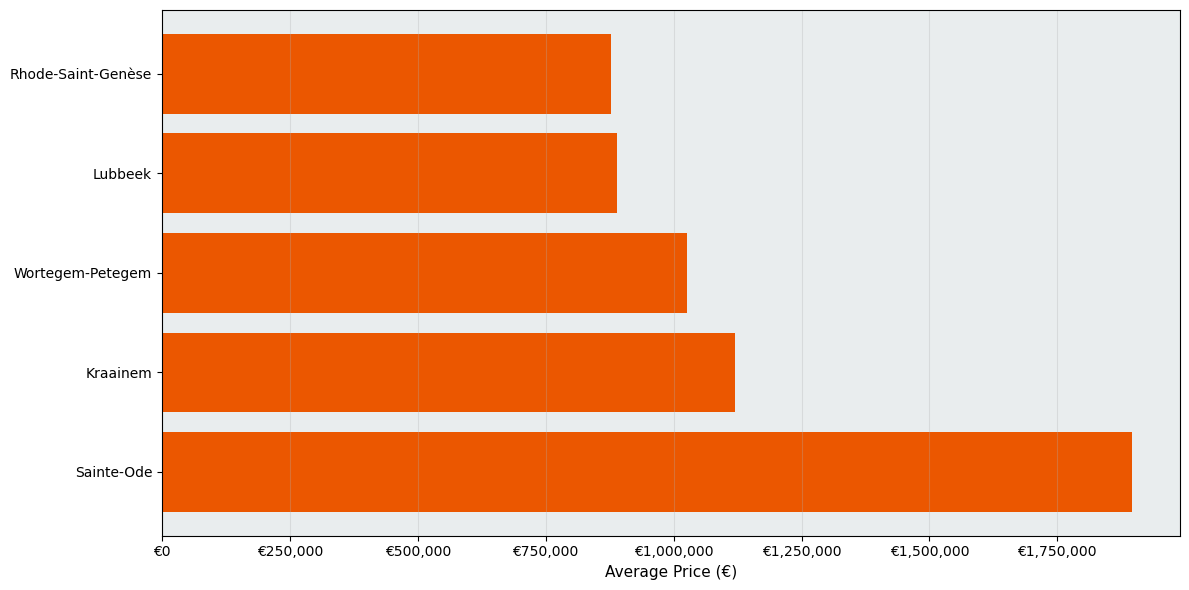

In [55]:
# Simple box plot for top 5 most expensive vs cheapest municipalities
# Get average price by municipality
municipality_avg = dataset.groupby('municipality')['price'].mean().sort_values(ascending=False)

# Plot top 5 most expensive and bottom 5 cheapest
top_5 = municipality_avg.head(5)
bottom_5 = municipality_avg.tail(5)
fig, ax = plt.subplots(figsize=(12, 6))

# Top 5 most expensive
top_bars = ax.barh(range(len(top_5)), top_5.values, color='#EB5700')
ax.set_yticks(range(len(top_5)))
ax.set_yticklabels(top_5.index)
ax.set_xlabel('Average Price (€)', fontsize=11)
ax.set_facecolor("#E9EDEE")

# ax.set_title('Top 5 Most Expensive Municipalities', fontweight='bold', fontsize=12)

# Format x-axis to show regular numbers (not scientific notation)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'€{x:,.0f}'))

ax.grid(axis='x', alpha=0.3)

# Adjust layout to prevent overlap
plt.subplots_adjust(hspace=0.3)  # Add space between the two plots
plt.tight_layout()
plt.show()
fig.savefig("plots/top5_expensive.png", bbox_inches="tight")

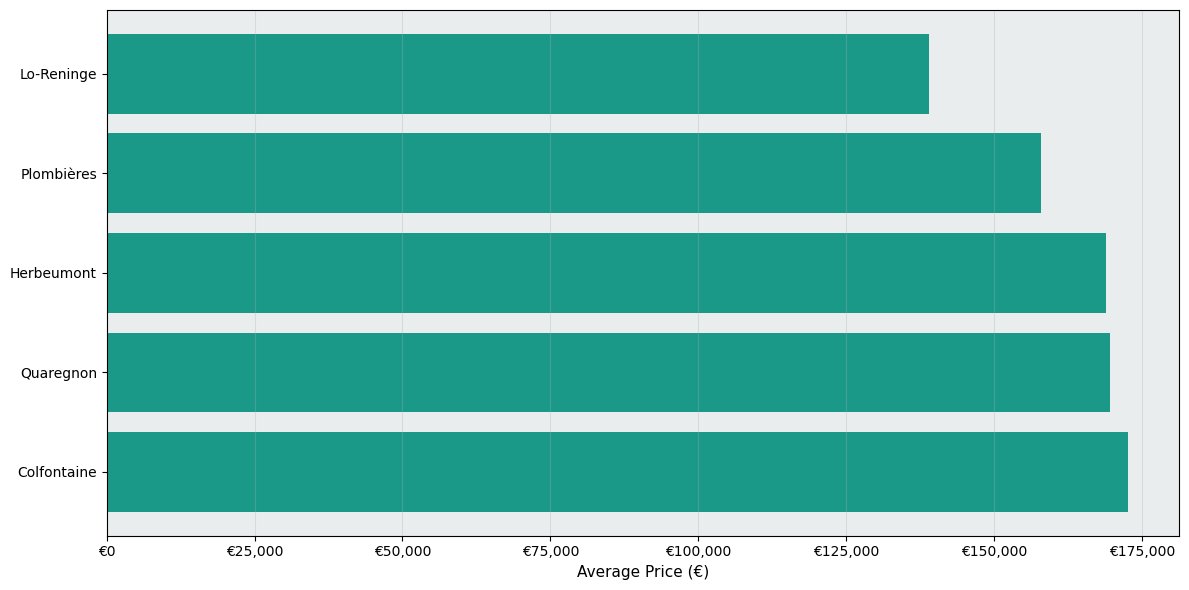

In [56]:
municipality_avg = dataset.groupby('municipality')['price'].mean().sort_values(ascending=False)

# Plot top 5 most expensive and bottom 5 cheapest
top_5 = municipality_avg.head(5)
bottom_5 = municipality_avg.tail(5)
fig, ax = plt.subplots(figsize=(12, 6))
bottom_bars = ax.barh(range(len(bottom_5)), bottom_5.values, color='#1A9988')
ax.set_yticks(range(len(bottom_5)))
ax.set_yticklabels(bottom_5.index)
ax.set_xlabel('Average Price (€)', fontsize=11)
ax.set_facecolor("#E9EDEE")
# ax.set_title('Top 5 Cheapest Municipalities', fontweight='bold', fontsize=12)

# Format x-axis to show regular numbers (not scientific notation)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'€{x:,.0f}'))

ax.grid(axis='x', alpha=0.3)



# Adjust layout to prevent overlap
plt.subplots_adjust(hspace=0.3)  # Add space between the two plots
plt.tight_layout()
plt.show()
fig.savefig("plots/top5_cheapest.png", bbox_inches="tight")